In [82]:
Subject='P1'

In [83]:
#统一时间戳并插值

import pandas as pd
import numpy as np
import glob
import os


def process_imu_fusion_perfect_sync(folder_path, output_filename=f'{Subject}_TimeAlign.csv'):
    file_list = glob.glob(os.path.join(folder_path, "*.csv"))
    if not file_list:
        print("未找到CSV文件！")
        return

    # 1. 扫描所有文件，确定全局时间锚点 (Global Anchor)
    # 我们需要找到所有文件中“最小”的那个时间戳，作为 t=0
    global_min_time = None
    global_max_time = None
    
    # 用于暂存读取的数据，避免重复IO
    raw_data_dict = {}

    print("Step 1: 扫描全局时间窗口...")
    for file in file_list:
        try:
            # 解析文件名
            filename = os.path.basename(file)
            parts = filename.split('_')
            sensor_id = parts[0] # S1, S2...
            
            # 识别类型
            filename_lower = filename.lower()
            if 'acc' in filename_lower: type_suffix = 'acc'
            elif 'gy' in filename_lower: type_suffix = 'gyro'
            else: continue

            # 读取
            df = pd.read_csv(file)
            df.columns = df.columns.str.strip()
            
            # 转为时间对象
            df['datetime'] = pd.to_datetime(df['epoc (ms)'], unit='ms')
            df = df.set_index('datetime').sort_index()
            # 去重
            df = df[~df.index.duplicated(keep='first')]

            # 更新全局范围
            t_start = df.index[0]
            t_end = df.index[-1]
            if global_min_time is None or t_start < global_min_time: global_min_time = t_start
            if global_max_time is None or t_end > global_max_time: global_max_time = t_end

            # 重命名列
            new_cols = {}
            for c in ['x-axis', 'y-axis', 'z-axis']:
                # 模糊匹配列名
                original_col = [col for col in df.columns if c in col]
                if original_col:
                    axis = c.split('-')[0] # x, y, z
                    new_cols[original_col[0]] = f"{sensor_id}_{type_suffix}_{axis}"
            
            df = df.rename(columns=new_cols)
            # 只保留数据列
            raw_data_dict[filename] = df[list(new_cols.values())]

        except Exception as e:
            print(f"Skipping {file}: {e}")

    print(f"全局时间起点: {global_min_time}")
    print(f"全局时间终点: {global_max_time}")

    # 2. 构建全局标准网格 (100Hz)
    # 无论传感器B何时启动，它都必须对齐到这个网格上
    target_index = pd.date_range(start=global_min_time, end=global_max_time, freq='10ms')
    final_df = pd.DataFrame(index=target_index)
    final_df.index.name = 'datetime'

    print("Step 2: 执行高精度对齐 (Resample & Interpolate)...")
    
    for fname, df in raw_data_dict.items():
        # --- 核心逻辑开始 ---
        
        # 场景：传感器B在 3.005s 启动，第一帧数据在 3.005s
        # 目标：我们需要 3.000s (空), 3.010s (插值值)
        
        # A. 将原始数据重新采样(Resample)或合并索引
        # 这里我们使用 union 索引法，保留原始的 3.005s 点，同时加入目标网格点
        combined_index = df.index.union(target_index)
        df_combined = df.reindex(combined_index)
        
        # B. 基于时间的插值
        # 这一步会利用 3.005s 的值和 3.015s 的值，计算出 3.010s 这个网格点的值
        # limit=10 防止长时间断联被错误连接，但在启动阶段这很重要
        # 注意：interpolate 默认不会向前填充 (not fill backward)，
        # 所以 3.005s 之前的所有网格点（比如 3.000s, 2.990s...）依然是 NaN。这正是我们想要的！
        df_interpolated = df_combined.interpolate(method='time', limit=100)
        
        # C. 抽取 (Downsample/Select)
        # 只取回落在 10ms 网格线上的点
        # 此时，3.005s 的原始数据被丢弃，留下了计算好的 3.010s 的值
        df_aligned = df_interpolated.reindex(target_index)
        
        # --- 核心逻辑结束 ---
        
        final_df = final_df.join(df_aligned)

    # 3. 整理输出
    final_df['epoc (ms)'] = (final_df.index.astype(np.int64) // 10**6)
    start_epoc = final_df.index[0]
    final_df['elapsed (s)'] = (final_df.index - start_epoc).total_seconds()
    final_df['timestamp'] = final_df.index.strftime('%Y-%m-%dT%H.%M.%S.%f').str[:-3]

    # 排序与导出
    cols = list(final_df.columns)
    # 简单把 timestamp 等放前面
    meta_cols = ['epoc (ms)', 'timestamp', 'elapsed (s)']
    data_cols = sorted([c for c in cols if c not in meta_cols])
    final_df = final_df[meta_cols + data_cols]
    
    # 统一保留3位小数
    final_df = final_df.round(3)

    final_df.to_csv(output_filename)
    print(f"处理完成: {output_filename}")

# 使用
#process_imu_fusion_perfect_sync(f'/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/{Subject}/cane walking')
process_imu_fusion_perfect_sync(f'/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/{Subject}/With_cane')

Step 1: 扫描全局时间窗口...
全局时间起点: 2024-03-16 03:08:09.439000
全局时间终点: 2024-03-16 03:14:24.547000
Step 2: 执行高精度对齐 (Resample & Interpolate)...
处理完成: P1_TimeAlign.csv


In [84]:
#剔除没有没有全部6个IMU的时间戳

import pandas as pd
import numpy as np

# 1. 读取数据
# 假设你的文件名是 Merged_6IMU_PerfectSync.csv
df = pd.read_csv(f'{Subject}_TimeAlign.csv', index_col='datetime')

# ==========================================
# 【关键修复步骤】
# 强制将索引转换为 Datetime 对象
df.index = pd.to_datetime(df.index)
# ==========================================

# 2. 剔除包含空值的行 (掐头去尾)
df_clean = df.dropna(how='any')

print(f"清洗前形状: {df.shape}")
print(f"清洗后形状: {df_clean.shape}")

# 3. 重置 elapsed (s) 为从 0.000 开始
if not df_clean.empty:
    start_time = df_clean.index[0]
    
    # 使用 .copy() 防止警告
    df_clean = df_clean.copy()
    
    # 现在索引已经是时间格式了，可以正常相减
    # 除以 1秒 (pd.Timedelta) 将其转换为浮点数秒
    df_clean['elapsed (s)'] = (df_clean.index - start_time) / pd.Timedelta(seconds=1)
    
    # 保留3位小数
    df_clean['elapsed (s)'] = df_clean['elapsed (s)'].round(3)

    # 4. 导出
    output_filename = f'{Subject}_InitialAlign.csv'
    df_clean.to_csv(output_filename)
    print(f"处理完成！文件已保存为: {output_filename}")
else:
    print("错误：清洗后数据为空，请检查数据完整性。")

清洗前形状: (37511, 39)
清洗后形状: (36988, 39)
处理完成！文件已保存为: P1_InitialAlign.csv


In [85]:
import pandas as pd
import numpy as np
import warnings
from scipy.signal import butter, filtfilt
try:
    from ahrs.filters import Madgwick
    HAS_AHRS = True
except ImportError:
    Madgwick = None
    HAS_AHRS = False
    warnings.warn("ahrs is not installed. Falling back to static gravity-vector subtraction.")
import matplotlib.pyplot as plt

# --- 参数设置 ---
FS = 100     # 采样频率
CUTOFF = 10.0
G = 9.80665  # 重力加速度 (m/s^2)
GYRO_INPUT_UNIT = 'deg/s'  # 原始 gyroscope CSV 表头为 deg/s

# 读取前一步清理后的数据
# 注意：输出的 GravityFilter 文件现在包含 SI 单位的 filtered acc/gyro，
# 以及真正的 gravity-compensated linear acceleration。
df = pd.read_csv(f'{Subject}_InitialAlign.csv')
sensors = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']


def _elapsed_at(df, idx):
    """Return elapsed time at a positional index for logging."""
    if 'elapsed (s)' in df.columns and len(df) > 0:
        idx = int(np.clip(idx, 0, len(df) - 1))
        return float(df['elapsed (s)'].iloc[idx])
    return np.nan


def find_static_period(df, sensors, fs=100, min_duration_sec=3.0, step_sec=0.5, gyro_weight=0.01):
    """Find the most stable >=3 s static window across available IMUs."""
    window_len = int(round(fs * min_duration_sec))
    step_len = max(1, int(round(fs * step_sec)))

    usable_sensors = []
    for s in sensors:
        acc_cols = [f'{s}_acc_x', f'{s}_acc_y', f'{s}_acc_z']
        gyro_cols = [f'{s}_gyro_x', f'{s}_gyro_y', f'{s}_gyro_z']
        missing = [c for c in acc_cols + gyro_cols if c not in df.columns]
        if missing:
            warnings.warn(f'{s}: missing columns for static detection, skipped: {missing}')
            continue
        usable_sensors.append(s)

    if not usable_sensors:
        warnings.warn('No usable IMU columns found for static detection. Falling back to the first available rows.')
        end_idx = min(len(df), max(1, window_len))
        return 0, end_idx, df.iloc[:end_idx].copy(), np.nan

    if len(df) < window_len:
        warnings.warn(f'Data length ({len(df)}) is shorter than the requested static window ({window_len}). Using the full dataframe.')
        return 0, len(df), df.copy(), np.nan

    best = {'score': np.inf, 'start': 0, 'end': window_len}
    for start in range(0, len(df) - window_len + 1, step_len):
        end = start + window_len
        acc_norm_stds = []
        gyro_norm_means = []
        gyro_norm_stds = []

        for s in usable_sensors:
            acc = df.loc[df.index[start:end], [f'{s}_acc_x', f'{s}_acc_y', f'{s}_acc_z']].to_numpy(dtype=float)
            gyro = df.loc[df.index[start:end], [f'{s}_gyro_x', f'{s}_gyro_y', f'{s}_gyro_z']].to_numpy(dtype=float)
            if np.isnan(acc).all() or np.isnan(gyro).all():
                continue
            acc_norm = np.linalg.norm(acc, axis=1)
            gyro_norm = np.linalg.norm(gyro, axis=1)
            acc_norm_stds.append(np.nanstd(acc_norm))
            gyro_norm_means.append(np.nanmean(np.abs(gyro_norm)))
            gyro_norm_stds.append(np.nanstd(gyro_norm))

        if not acc_norm_stds or not gyro_norm_means:
            continue

        score = (np.nanmean(acc_norm_stds)
                 + gyro_weight * np.nanmean(gyro_norm_means)
                 + gyro_weight * np.nanmean(gyro_norm_stds))
        if np.isfinite(score) and score < best['score']:
            best = {'score': float(score), 'start': start, 'end': end}

    static_start_idx = best['start']
    static_end_idx = best['end']
    static_period = df.iloc[static_start_idx:static_end_idx].copy()

    print('=== Auto static period detection ===')
    print(f'usable sensors: {usable_sensors}')
    print(f'static index range: {static_start_idx} - {static_end_idx}')
    print(f'static elapsed range: {_elapsed_at(df, static_start_idx):.3f}s - {_elapsed_at(df, static_end_idx - 1):.3f}s')
    print(f'stability score: {best["score"]:.6f}')

    return static_start_idx, static_end_idx, static_period, best['score']


# ---------- 用重力对齐（只校正 roll/pitch，忽略 yaw） ----------
def align_to_gravity(acc_mean, g_world=np.array([0, 0, -1.0])):
    """Build a rotation matrix that aligns the static acceleration vector to gravity."""
    acc_mean = np.asarray(acc_mean, dtype=float)
    if not np.all(np.isfinite(acc_mean)) or np.linalg.norm(acc_mean) == 0:
        warnings.warn('Invalid static acceleration mean; using identity alignment.')
        return np.eye(3)

    acc_mean = acc_mean / np.linalg.norm(acc_mean)
    g_world = g_world / np.linalg.norm(g_world)
    v = np.cross(acc_mean, g_world)
    s = np.linalg.norm(v)
    c = np.clip(np.dot(acc_mean, g_world), -1.0, 1.0)
    if s < 1e-12:
        if c > 0:
            return np.eye(3)
        axis = np.array([1, 0, 0]) if abs(acc_mean[0]) < 0.9 else np.array([0, 1, 0])
        axis = axis / np.linalg.norm(axis)
        return -np.eye(3) + 2 * np.outer(axis, axis)

    # Rodrigues formula with K built from the raw cross-product vector v.
    # This keeps R_align orthonormal and preserves acceleration/gyro magnitudes.
    K = np.array([[0, -v[2], v[1]],
                  [v[2], 0, -v[0]],
                  [-v[1], v[0], 0]])
    R_align = np.eye(3) + K + K @ K * ((1 - c) / (s**2))
    return R_align


def calibrate_and_align(df, sensor_prefix, static_period):
    """Remove gyro bias and align acc/gyro axes using the detected static period."""
    acc_cols = [f'{sensor_prefix}_acc_x', f'{sensor_prefix}_acc_y', f'{sensor_prefix}_acc_z']
    gyro_cols = [f'{sensor_prefix}_gyro_x', f'{sensor_prefix}_gyro_y', f'{sensor_prefix}_gyro_z']
    missing = [c for c in acc_cols + gyro_cols if c not in df.columns]
    if missing:
        warnings.warn(f'{sensor_prefix}: missing columns for bias removal/alignment, skipped: {missing}')
        return df

    # gyro 去偏置，bias 来自自动检测到的静止阶段
    for col in gyro_cols:
        bias = static_period[col].mean()
        df[col] = df[col] - bias

    # 静止阶段平均加速度估计重力方向
    acc_mean = static_period[acc_cols].mean().to_numpy(dtype=float)
    R_align = align_to_gravity(acc_mean, np.array([0, 0, -1.0]))

    # 对整个序列 acc 和 gyro 做同样的 roll/pitch 对齐，保留原有处理逻辑
    df.loc[:, acc_cols] = df[acc_cols].to_numpy(dtype=float) @ R_align.T
    df.loc[:, gyro_cols] = df[gyro_cols].to_numpy(dtype=float) @ R_align.T
    return df


def butter_lowpass_filter(data, cutoff, fs, order=4):
    """Apply low-pass filtering with NaN interpolation and short-signal fallback."""
    series = pd.Series(data, dtype='float64').interpolate(limit_direction='both')
    values = series.to_numpy(dtype=float)
    if len(values) == 0:
        return values
    if np.isnan(values).any():
        warnings.warn('Filter input still contains NaN after interpolation; returning unfiltered values.')
        return values

    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    padlen = 3 * max(len(a), len(b))
    if len(values) <= padlen:
        warnings.warn(f'Signal too short for filtfilt (n={len(values)}, padlen={padlen}); returning unfiltered values.')
        return values
    return filtfilt(b, a, values)


def _acc_input_unit_from_static(static_acc_values):
    """Infer whether acceleration columns are in g or m/s^2 from a static segment."""
    static_norm = np.nanmedian(np.linalg.norm(static_acc_values, axis=1))
    if np.isfinite(static_norm) and static_norm < 3.0:
        return 'g'
    return 'm/s^2'


def _acc_to_mps2(acc_values, static_acc_values):
    """Convert acceleration arrays or single-axis signals to m/s^2."""
    acc_unit = _acc_input_unit_from_static(static_acc_values)
    if acc_unit == 'g':
        return acc_values * G, acc_unit
    return acc_values, acc_unit


def _gyro_to_rads(gyro_values):
    """Convert gyroscope data to rad/s using the source CSV unit."""
    if GYRO_INPUT_UNIT.lower() in ['deg/s', 'dps', 'degree/s', 'degrees/s']:
        return np.deg2rad(gyro_values), 'deg/s'
    return gyro_values, 'rad/s'


def _quaternion_from_two_vectors(v_from, v_to):
    """Quaternion [w, x, y, z] rotating v_from onto v_to."""
    v_from = np.asarray(v_from, dtype=float)
    v_to = np.asarray(v_to, dtype=float)
    v_from = v_from / np.linalg.norm(v_from)
    v_to = v_to / np.linalg.norm(v_to)
    dot = np.clip(np.dot(v_from, v_to), -1.0, 1.0)

    if dot < -0.999999:
        axis = np.array([1.0, 0.0, 0.0]) if abs(v_from[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
        axis = axis - v_from * np.dot(v_from, axis)
        axis = axis / np.linalg.norm(axis)
        return np.array([0.0, axis[0], axis[1], axis[2]])

    q_xyz = np.cross(v_from, v_to)
    q = np.array([1.0 + dot, q_xyz[0], q_xyz[1], q_xyz[2]])
    return q / np.linalg.norm(q)


def _gravity_from_quaternion(Q):
    """Return gravity vector in the sensor/aligned frame from ahrs quaternions."""
    qw, qx, qy, qz = Q[:, 0], Q[:, 1], Q[:, 2], Q[:, 3]
    gravity_unit = np.column_stack([
        2.0 * (qx * qz - qw * qy),
        2.0 * (qw * qx + qy * qz),
        2.0 * (0.5 - qx**2 - qy**2)
    ])
    return gravity_unit * G


def estimate_orientation_and_remove_gravity(df, sensor, static_period, fs=100):
    """Estimate IMU orientation and write gravity-compensated linear acceleration columns."""
    acc_cols = [f'{sensor}_acc_x', f'{sensor}_acc_y', f'{sensor}_acc_z']
    gyro_cols = [f'{sensor}_gyro_x', f'{sensor}_gyro_y', f'{sensor}_gyro_z']
    linacc_cols = [f'{sensor}_linacc_x', f'{sensor}_linacc_y', f'{sensor}_linacc_z']
    gravity_acc_col = f'{sensor}_linacc_gravity'
    missing = [c for c in acc_cols + gyro_cols if c not in df.columns]
    if missing:
        warnings.warn(f'{sensor}: missing columns for gravity compensation, skipped: {missing}')
        return df

    acc_values = df[acc_cols].to_numpy(dtype=float)
    static_acc_values = static_period[acc_cols].to_numpy(dtype=float)
    acc_ms2, acc_unit = _acc_to_mps2(acc_values, static_acc_values)

    gyro_values = df[gyro_cols].to_numpy(dtype=float)
    gyro_rads, gyro_unit = _gyro_to_rads(gyro_values)

    static_acc_ms2 = static_period[acc_cols].to_numpy(dtype=float)
    static_acc_ms2, _ = _acc_to_mps2(static_acc_ms2, static_acc_ms2)
    static_acc_mean = np.nanmean(static_acc_ms2, axis=0)
    if not np.all(np.isfinite(static_acc_mean)) or np.linalg.norm(static_acc_mean) == 0:
        warnings.warn(f'{sensor}: invalid static acceleration for gravity compensation, skipped.')
        return df

    q0 = _quaternion_from_two_vectors(np.array([0.0, 0.0, 1.0]), static_acc_mean)

    if HAS_AHRS:
        Q = np.zeros((len(df), 4), dtype=float)
        Q[0] = q0
        madgwick = Madgwick(frequency=fs)
        for i in range(1, len(df)):
            if np.all(np.isfinite(gyro_rads[i])) and np.all(np.isfinite(acc_ms2[i])):
                Q[i] = madgwick.updateIMU(Q[i - 1], gyr=gyro_rads[i], acc=acc_ms2[i])
            else:
                Q[i] = Q[i - 1]
        gravity_sensor = _gravity_from_quaternion(Q)
        method = 'Madgwick IMU'
    else:
        gravity_sensor = np.tile(static_acc_mean, (len(df), 1))
        method = 'static gravity vector fallback'

    linacc = acc_ms2 - gravity_sensor

    # 去除静止阶段残余均值，保证静止期 linear acceleration 接近 0
    static_idx = static_period.index.to_numpy()
    residual = np.nanmean(linacc[static_idx, :], axis=0)
    linacc = linacc - residual

    # 将线性加速度投影到瞬时重力方向；正值表示沿重力方向（向下）
    gravity_norm = np.linalg.norm(gravity_sensor, axis=1, keepdims=True)
    gravity_unit = np.divide(
        gravity_sensor,
        gravity_norm,
        out=np.full_like(gravity_sensor, np.nan),
        where=gravity_norm > 0,
    )
    gravity_direction_acc = np.einsum('ij,ij->i', linacc, gravity_unit)

    df.loc[:, linacc_cols] = linacc
    df.loc[:, gravity_acc_col] = gravity_direction_acc
    static_mean = df.loc[static_idx, linacc_cols].mean().to_numpy(dtype=float)
    print(f'{sensor}: gravity compensation = {method}; acc unit={acc_unit}, gyro unit={gyro_unit}; '
          f'static linacc mean [m/s^2] = {np.round(static_mean, 4)}')
    return df


# ---------- 自动寻找静止阶段 ----------
static_start_idx, static_end_idx, static_period, static_score = find_static_period(
    df, sensors, fs=FS, min_duration_sec=3.0
)
static_summary = {
    'start_idx': static_start_idx,
    'end_idx': static_end_idx,
    'start_elapsed': _elapsed_at(df, static_start_idx),
    'end_elapsed': _elapsed_at(df, static_end_idx - 1),
    'score': static_score,
}

# ---------- gyro bias 去除 + 重力方向对齐 ----------
for s in sensors:
    df = calibrate_and_align(df, s, static_period)

# 对齐后的静止阶段，用于 Madgwick 初始姿态和 linacc 静止残差校正
static_period_aligned = df.iloc[static_start_idx:static_end_idx].copy()

# ---------- 低通滤波：输出 SI 单位的 acc/gyro filtered 列 ----------
for s in sensors:
    acc_candidates = [f'{s}_acc_x', f'{s}_acc_y', f'{s}_acc_z']
    gyro_candidates = [f'{s}_gyro_x', f'{s}_gyro_y', f'{s}_gyro_z']
    filter_candidates = acc_candidates + gyro_candidates
    missing = [c for c in filter_candidates if c not in df.columns]
    if missing:
        warnings.warn(f'{s}: missing columns during acc/gyro filtering, skipped missing columns: {missing}')

    static_acc_values = None
    if all(c in static_period_aligned.columns for c in acc_candidates):
        static_acc_values = static_period_aligned[acc_candidates].to_numpy(dtype=float)
        acc_input_unit = _acc_input_unit_from_static(static_acc_values)
    else:
        acc_input_unit = 'unknown'
        warnings.warn(f'{s}: cannot infer acc unit from static period; acc filtered columns will be left unchanged.')

    gyro_input_unit = GYRO_INPUT_UNIT
    acc_written = False
    gyro_written = False
    for src in filter_candidates:
        if src not in df.columns:
            continue
        filtered_values = butter_lowpass_filter(df[src].values, CUTOFF, FS)
        if src in acc_candidates:
            if static_acc_values is not None:
                filtered_values, acc_input_unit = _acc_to_mps2(filtered_values, static_acc_values)
            acc_written = True
        elif src in gyro_candidates:
            filtered_values, gyro_input_unit = _gyro_to_rads(filtered_values)
            gyro_written = True
        df[f'{src}_filtered'] = filtered_values

    acc_msg = f'filtered acc saved in m/s^2 (input {acc_input_unit})' if acc_written else 'filtered acc columns missing'
    gyro_msg = f'filtered gyro saved in rad/s (input {gyro_input_unit})' if gyro_written else 'filtered gyro columns missing'
    print(f'{s}: {acc_msg}; {gyro_msg}.')

# ---------- 真正执行重力补偿，输出 linear acceleration ----------
for s in sensors:
    df = estimate_orientation_and_remove_gravity(df, s, static_period_aligned, fs=FS)

# ---------- linear acceleration 低通滤波 ----------
for s in sensors:
    linacc_candidates = [
        f'{s}_linacc_x', f'{s}_linacc_y', f'{s}_linacc_z', f'{s}_linacc_gravity'
    ]
    missing = [c for c in linacc_candidates if c not in df.columns]
    if missing:
        warnings.warn(f'{s}: missing linacc columns during filtering, skipped: {missing}')
    for src in linacc_candidates:
        if src in df.columns:
            df[f'{src}_filtered'] = butter_lowpass_filter(df[src].values, CUTOFF, FS)

output_filename = f'{Subject}_GravityFilter.csv'
df.to_csv(output_filename, index=False)
print(f'处理完成，数据已保存: {output_filename}')
print('说明：S*_acc_*_filtered 已转换为 m/s^2；S*_gyro_*_filtered 已转换为 rad/s；S*_linacc_*_filtered 为 m/s^2。')


=== Auto static period detection ===
usable sensors: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
static index range: 3450 - 3750
static elapsed range: 34.500s - 37.490s
stability score: 0.059414
S1: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S2: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S3: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S4: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S5: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S6: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S1: gravity compensation = Madgwick IMU; acc unit=g, gyro unit=deg/s; static linacc mean [m/s^2] = [-0.  0. -0.]
S2: gravity compensation = Madgwick IMU; acc unit=g, gyro unit=deg/s; static linacc mean [m/s^2] = [-0.  0.  0.]
S3: gravity compensation = Madgwick IMU; acc unit=g, gyro unit=d

/tmp/ipykernel_4039235/1134528539.py:362: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{src}_filtered'] = butter_lowpass_filter(df[src].values, CUTOFF, FS)
/tmp/ipykernel_4039235/1134528539.py:362: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{src}_filtered'] = butter_lowpass_filter(df[src].values, CUTOFF, FS)
/tmp/ipykernel_4039235/1134528539.py:362: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

处理完成，数据已保存: P1_GravityFilter.csv
说明：S*_acc_*_filtered 已转换为 m/s^2；S*_gyro_*_filtered 已转换为 rad/s；S*_linacc_*_filtered 为 m/s^2。


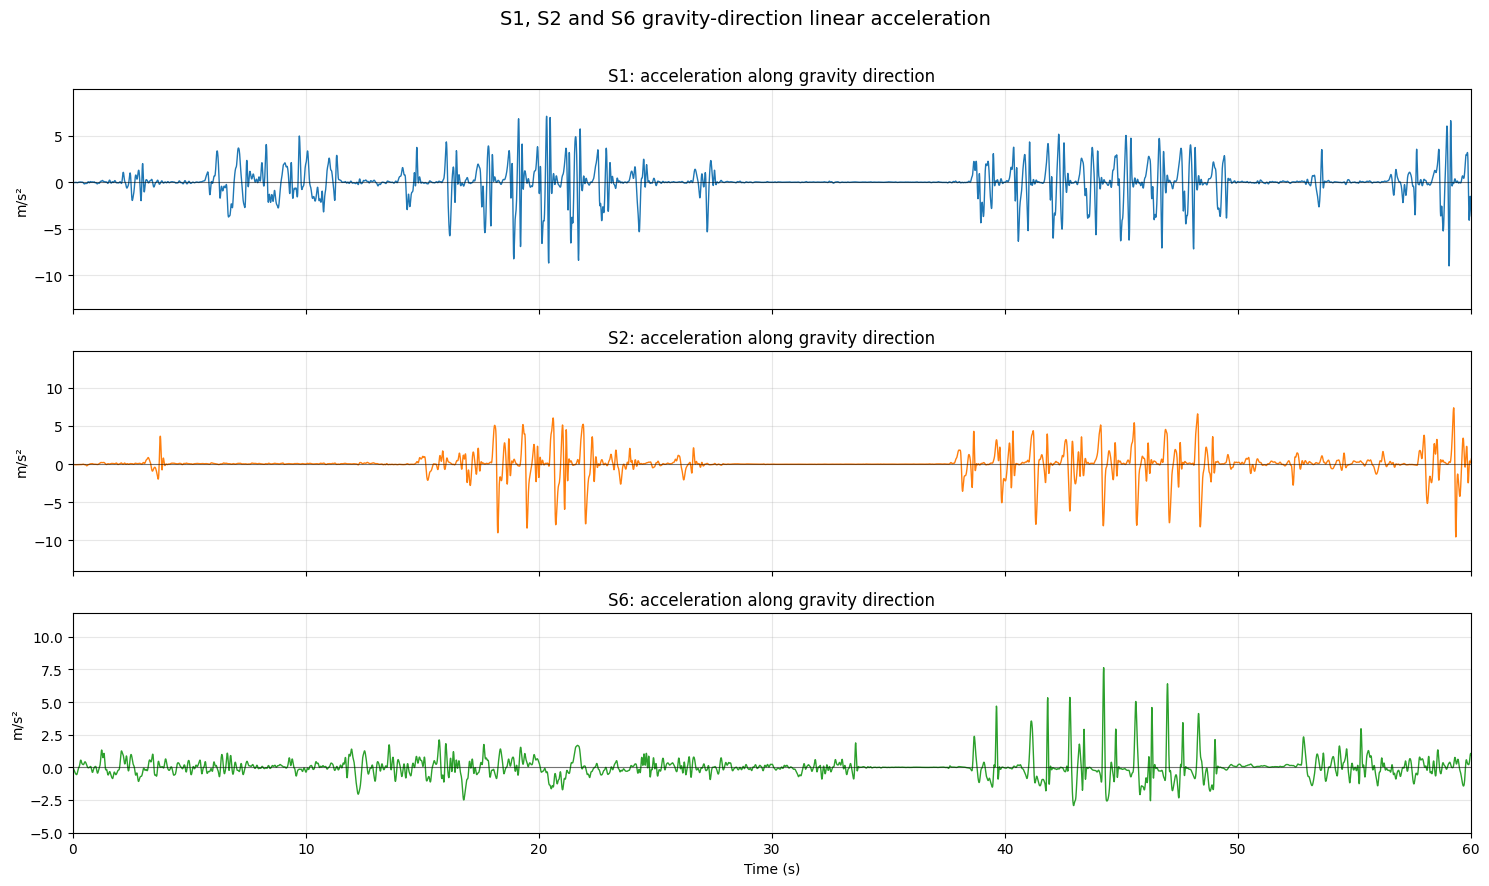

In [86]:
# 展示 S1、S2、S6 在瞬时重力方向上的线性加速度
plot_sensors = ['S1', 'S2', 'S6']
gravity_columns = [f'{sensor}_linacc_gravity_filtered' for sensor in plot_sensors]
missing_columns = [column for column in gravity_columns if column not in df.columns]
if missing_columns:
    raise KeyError(f'缺少重力方向加速度列，请先运行上一个重力补偿单元: {missing_columns}')

if 'elapsed (s)' in df.columns:
    plot_time = df['elapsed (s)'].to_numpy(dtype=float)
    x_label = 'Time (s)'
else:
    plot_time = np.arange(len(df), dtype=float) / FS
    x_label = 'Time (s, derived from sample index)'

fig, axes = plt.subplots(len(plot_sensors), 1, figsize=(15, 9), sharex=True)
colors = ['tab:blue', 'tab:orange', 'tab:green']
for ax, sensor, column, color in zip(axes, plot_sensors, gravity_columns, colors):
    ax.plot(plot_time, df[column].to_numpy(dtype=float), color=color, linewidth=1.0)
    ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{sensor}: acceleration along gravity direction')
    ax.set_ylabel('m/s²')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(x_label)

axes[-1].set_xlim(0, 60)  # 调整这里的起止时间（秒）来设置 x 轴范围

fig.suptitle('S1, S2 and S6 gravity-direction linear acceleration', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
